<a href="https://colab.research.google.com/github/guanyuq03/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Assignment%205/Assignment_5_The_Sovereign_Risk_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import wbgapi as wb
np.random.seed(42)

In [3]:
INDICATORS = {
    # Growth outcome (our y)
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Natural Resources
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',

    # Agriculture
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    # Governance (World Bank Governance Indicators)
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

# Pull country-year-panel data from WDI
raw_data = wb.data.DataFrame(
    list(INDICATORS.keys()),
    time=range(2013, 2020),
    skipBlanks=True,
    labels= False
)

print("Raw data shape:", raw_data.shape)
display(raw_data.head())

Raw data shape: (7211, 7)


YR2013      YR2014        YR2015  \
economy series                                                       
ABW     AG.LND.ARBL.ZS         11.111111   11.111111     11.111111   
        BN.CAB.XOKA.GD.ZS     -11.813209   -4.658577      3.994142   
        BX.GSR.ROYL.CD         75.054503   67.345643  17247.742744   
        BX.KLT.DINV.WD.GD.ZS    9.974457    7.465255     -0.907264   
        EG.ELC.ACCS.ZS        100.000000  100.000000    100.000000   

                                    YR2016       YR2017         YR2018  \
economy series                                                           
ABW     AG.LND.ARBL.ZS           11.111111    11.111111      11.111111   
        BN.CAB.XOKA.GD.ZS         4.731774     1.119796      -0.591366   
        BX.GSR.ROYL.CD        33607.017326  8565.609832  932986.795265   
        BX.KLT.DINV.WD.GD.ZS      0.923397     5.253375       4.399817   
        EG.ELC.ACCS.ZS          100.000000   100.000000     100.000000   

                                    YR2019  
economy series                              
ABW     AG.LND.ARBL.ZS        1.111111e+01  
        BN.CAB.XOKA.GD.ZS     2.533802e+00  
        BX.GSR.ROYL.CD        1.750298e+06  
        BX.KLT.DINV.WD.GD.ZS -2.247834e+00  
        EG.ELC.ACCS.ZS        1.000000e+02

In [4]:
# Collapse to country-level
if isinstance(raw_data.index, pd.MultiIndex):
    averaged_by_series = raw_data.mean(axis=1)
    country_data = averaged_by_series.unstack(level='series')
    country_data = country_data.rename(columns=INDICATORS)
else:
    country_data = raw_data.copy()

print("Initial country-level shape:", country_data.shape)
display(country_data.head())

# Keep rows or columns with at least 60% observed values
threshold = 0.60

# Drop countries with too much missingness
country_data = country_data.dropna(thresh=int(threshold * country_data.shape[1]))

# Drop indicators with too much missingness
country_data = country_data.dropna(axis=1, thresh=int(threshold * len(country_data)))

# Median imputation for remaining gaps
country_data = country_data.fillna(country_data.median(numeric_only=True))

print(f"Final cleaned dataset: {country_data.shape[0]} countries × {country_data.shape[1]} variables")
print("\nColumns retained:")
print(country_data.columns.tolist())

Initial country-level shape: (265, 35)


series,arable_land_pct,current_account_pct_gdp,royalties_receipts,fdi_inflows_pct_gdp,market_cap_pct_gdp,electricity_access_pct,renewable_energy_pct,atms_per100k,private_credit_pct_gdp,inflation_cpi,...,secondary_enrollment_gross,tertiary_enrollment_gross,education_expenditure_pct_gdp,infant_mortality_per1000,health_expenditure_pct_gdp,unemployment_rate,life_expectancy,population_growth,urbanization_pct,tariff_rate_avg
economy,,,,,,,,,,,,,,,,,,,,,
ABW,11.111111,-0.669091,3.918354e+05,3.551600,NaN,100.000000,7.314286,123.843123,58.016290,0.635452,...,138.575188,17.187657,5.301927,NaN,NaN,NaN,75.542429,0.682293,62.988008,10.186667
AFE,8.096816,NaN,2.582984e+08,1.994010,NaN,37.718154,61.605147,8.029037,37.151340,5.404875,...,42.748069,8.517323,4.677735,67.560088,5.862101,7.096626,62.258202,2.698276,34.887403,NaN
AFG,11.900053,-19.805290,1.606758e+05,0.415848,NaN,87.928571,18.657143,1.128242,3.676093,3.383775,...,54.776075,9.196780,3.858524,69.728571,11.702762,9.792429,62.450571,3.058566,24.585807,7.665000
AFW,11.932068,NaN,3.419290e+07,2.024465,11.936331,49.199649,75.868295,4.864819,13.585211,1.902643,...,43.429490,9.424783,2.888076,103.940671,3.580767,4.134629,56.356506,2.633388,48.171470,NaN
AGO,4.166084,0.248949,1.279839e+07,-1.996599,NaN,41.142857,49.357143,17.853955,16.293914,17.523280,...,54.416799,9.263161,2.900706,60.500000,2.316813,16.513714,61.508143,3.592279,64.327626,9.648333


Final cleaned dataset: 238 countries × 29 variables

Columns retained:
['arable_land_pct', 'current_account_pct_gdp', 'royalties_receipts', 'fdi_inflows_pct_gdp', 'electricity_access_pct', 'renewable_energy_pct', 'atms_per100k', 'private_credit_pct_gdp', 'inflation_cpi', 'real_interest_rate', 'govt_expenditure_pct_gdp', 'mobile_subscriptions_per100', 'internet_users_pct', 'trade_pct_gdp', 'agriculture_pct_gdp', 'gdp_growth_pc', 'natural_resource_rents_pct_gdp', 'exchange_rate_official', 'adult_literacy_rate', 'secondary_enrollment_gross', 'tertiary_enrollment_gross', 'education_expenditure_pct_gdp', 'infant_mortality_per1000', 'health_expenditure_pct_gdp', 'unemployment_rate', 'life_expectancy', 'population_growth', 'urbanization_pct', 'tariff_rate_avg']


In [5]:
# Define outcomes
country_data['crisis'] = (country_data['gdp_growth_pc'] < 0).astype(int)

# Features exclude both outcomes
feature_cols = [c for c in country_data.columns if c not in ['gdp_growth_pc', 'crisis']]

X = country_data[feature_cols].values
y_cont = country_data['gdp_growth_pc'].values
y_bin = country_data['crisis'].values

print("Number of predictors:", len(feature_cols))
print("Number of crisis countries:", int(country_data['crisis'].sum()))
print("Number of non-crisis countries:", int((country_data['crisis'] == 0).sum()))
print("Crisis base rate:", round(country_data['crisis'].mean(), 3))

Number of predictors: 28
Number of crisis countries: 38
Number of non-crisis countries: 200
Crisis base rate: 0.16


In [6]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cont, test_size=0.30, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training observations: {X_train.shape[0]}")
print(f"Test observations: {X_test.shape[0]}")
print(f"Predictors (p): {X_train.shape[1]}")
print(f"Predictor-to-observation ratio (p/n): {X_train.shape[1]}/{X_train.shape[0]} = {X_train.shape[1] / X_train.shape[0]:.3f}")

Training observations: 166
Test observations: 72
Predictors (p): 28
Predictor-to-observation ratio (p/n): 28/166 = 0.169


<h1> Phase 1: The Complexity Trap — OLS Failure and Regularization Rescue

<h2> Step 1.1: Demonstrating OLS Overfitting

In [7]:
ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = ols_model.predict(X_train_scaled)
y_test_pred = ols_model.predict(X_test_scaled)

# R^2
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
r2_gap = train_r2 - test_r2

# p/n ratio
p = X_train.shape[1]
n = X_train.shape[0]
pn_ratio = p / n

print("-" * 50)
print("OLS OVERFITTING DIAGNOSTIC")
print("-" * 50)
print(f"Training R²: {train_r2:.4f}")
print(f"Test R²:     {test_r2:.4f}")
print(f"Train-Test R² Gap: {r2_gap:.4f}")
print(f"Predictor-to-observation ratio (p/n): {p}/{n} = {pn_ratio:.4f}")
print("-" * 50)

--------------------------------------------------
OLS OVERFITTING DIAGNOSTIC
--------------------------------------------------
Training R²: 0.6034
Test R²:     -0.9141
Train-Test R² Gap: 1.5175
Predictor-to-observation ratio (p/n): 28/166 = 0.1687
--------------------------------------------------


The OLS model shows a large gap between training R² (0.6034) and test R² (-0.9141). This indicates severe overfitting. With a relatively high predictor-to-observation ratio (p/n ≈ 0.17), the model has too many degrees of freedom and fits noise in the training data rather than the true signal. As a result, this causes low bias but high variance, leading to poor generalization performance on the test set.

<h2> Step 1.2: Ridge and Lasso to the Rescue

In [8]:
# Candidate lambda grid
alphas = np.logspace(-3, 3, 100)

# Ridge
ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train_scaled, y_train)

ridge_train_pred = ridge.predict(X_train_scaled)
ridge_test_pred = ridge.predict(X_test_scaled)

ridge_train_r2 = r2_score(y_train, ridge_train_pred)
ridge_test_r2 = r2_score(y_test, ridge_test_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_test_pred))

ridge_nonzero = np.sum(ridge.coef_ != 0)

# Lasso
lasso = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

lasso_train_pred = lasso.predict(X_train_scaled)
lasso_test_pred = lasso.predict(X_test_scaled)

lasso_train_r2 = r2_score(y_train, lasso_train_pred)
lasso_test_r2 = r2_score(y_test, lasso_test_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_test_pred))

lasso_nonzero = np.sum(lasso.coef_ != 0)

# OLS RMSE
ols_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))


# Model Comparison Table
comparison_df = pd.DataFrame({
    "Model": ["OLS", "Ridge", "Lasso"],
    "λ* (alpha)": ["N/A", ridge.alpha_, lasso.alpha_],
    "Non-zero Predictors": [
        p,
        ridge_nonzero,
        lasso_nonzero
    ],
    "Training R²": [
        train_r2,
        ridge_train_r2,
        lasso_train_r2
    ],
    "Test R²": [
        test_r2,
        ridge_test_r2,
        lasso_test_r2
    ],
    "Test RMSE": [
        ols_rmse,
        ridge_rmse,
        lasso_rmse
    ]
})

comparison_df

,Model,λ* (alpha),Non-zero Predictors,Training R²,Test R²,Test RMSE
0,OLS,N/A,28,0.603380,-0.914092,2.922676
1,Ridge,46.415888,28,0.560089,-0.072612,2.187866
2,Lasso,0.065793,18,0.573584,-0.356560,2.460474


I would recommend Ridge for IMF operational forecasting because it achieves the best out-of-sample performance, with the highest test R² and lowest RMSE among the models. Ridge and Lasso both introduce bias by shrinking coefficients, but this reduces variance and improves generalization; however, Ridge retains all predictors and provides more stable predictions, while Lasso sacrifices additional information through variable selection, leading to weaker predictive accuracy in this case.

<h2> Step 1.3: The Lasso Path — Which Indicators Enter First?

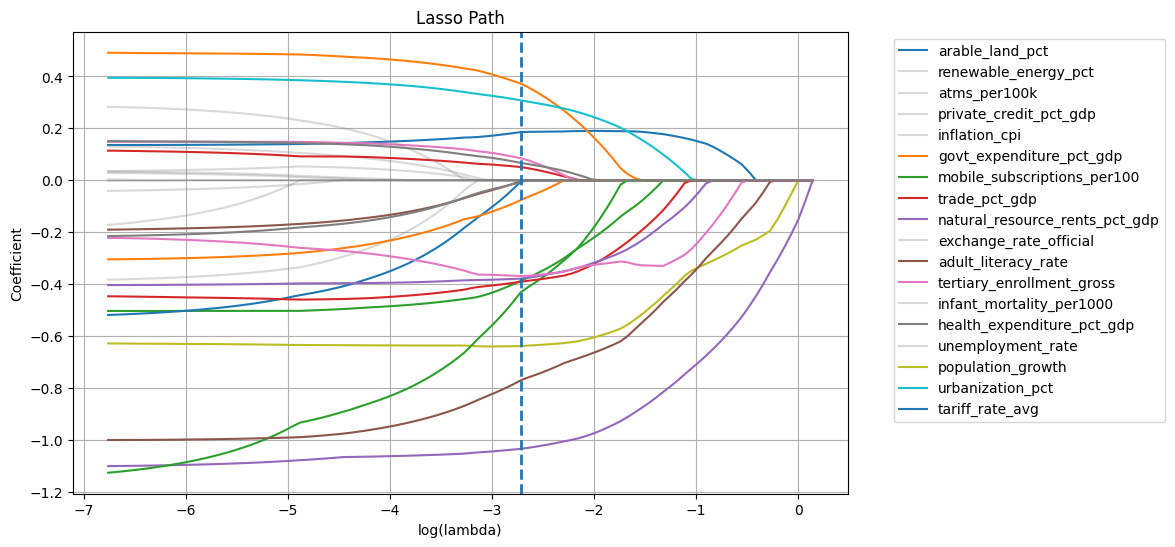

In [9]:
# Compute Lasso path
alphas_lasso, coefs_lasso, _ = lasso_path(X_train_scaled, y_train)

# Convert to dataframe
coef_df = pd.DataFrame(coefs_lasso.T, columns=feature_cols)
coef_df['alpha'] = alphas_lasso

alpha_star = lasso.alpha_

coef_at_star = lasso.coef_
nonzero_features = [feature_cols[i] for i in range(len(feature_cols)) if coef_at_star[i] != 0]

# Plot Lasso Path

plt.figure(figsize=(10, 6))

for i, col in enumerate(feature_cols):
    if col in nonzero_features:
        plt.plot(np.log(alphas_lasso), coefs_lasso[i], label=col)
    else:
        plt.plot(np.log(alphas_lasso), coefs_lasso[i], color='gray', alpha=0.3)

# vertical line at lambda
plt.axvline(np.log(alpha_star), linestyle='--', linewidth=2)

plt.xlabel("log(lambda)")
plt.ylabel("Coefficient")
plt.title("Lasso Path")
plt.grid(True)

plt.legend(nonzero_features, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

The colleague’s interpretation is incorrect because Lasso performs variable selection based on conditional predictive redundancy, not overall importance. Life expectancy may be highly correlated with other variables such as education, income, or infrastructure, meaning its predictive contribution is already captured by those variables in the model. In fact, this reflects the correlation structure of cross-country macroeconomic data, where many indicators measure similar underlying development factors. So, Lasso may set life_expectancy to zero even though health remains an important driver of economic growth.

<h1> Phase 2: The Crisis Classifier — From Forecasting to Classification

<h2> Step 2.1: The Linear Probability Model — Exposing the Failure

In [10]:
lasso_features = [feature_cols[i] for i in range(len(feature_cols)) if lasso.coef_[i] != 0]

X_train_lasso = pd.DataFrame(X_train_scaled, columns=feature_cols)[lasso_features].values
X_test_lasso = pd.DataFrame(X_test_scaled, columns=feature_cols)[lasso_features].values

y_train_bin = y_bin[train_test_split(range(len(y_bin)), test_size=0.30, random_state=42)[0]]
y_test_bin = y_bin[train_test_split(range(len(y_bin)), test_size=0.30, random_state=42)[1]]

# LPM = OLS on binary outcome
lpm = LinearRegression()
lpm.fit(X_train_lasso, y_train_bin)

# Predictions
y_pred_lpm = lpm.predict(X_test_lasso)

# Count invalid probabilities
below_zero = np.sum(y_pred_lpm < 0)
above_one = np.sum(y_pred_lpm > 1)

print("Predictions < 0:", below_zero)
print("Predictions > 1:", above_one)
print("Total invalid predictions:", below_zero + above_one)

Predictions < 0: 13
Predictions > 1: 1
Total invalid predictions: 14


The Linear Probability Model produces 14 invalid predicted probabilities in the test set, including 13 values below 0 and 1 value above 1. Predicted probabilities outside the [0, 1] range are a fundamental problem because they violate the definition of probability itself and cannot be meaningfully interpreted. For example, a “−12% probability of crisis” has no economic meaning and cannot support decision-making, which makes the model unsuitable for IMF policy use.

<h2> Step 2.2: Logistic Regression — The Sigmoid Fix

In [11]:
from sklearn.linear_model import LogisticRegression
# Fit logistic regression
logit = LogisticRegression(max_iter=10000)
logit.fit(X_train_lasso, y_train_bin)

# Coefficients
coefficients = pd.DataFrame({
    "Feature": lasso_features,
    "Beta (Coefficient)": logit.coef_[0]
})

# Intercept
intercept = logit.intercept_[0]

print("Intercept (β₀):", intercept)
coefficients

Intercept (β₀): -3.0262461294777867


,Feature,Beta (Coefficient)
0,arable_land_pct,-0.950383
1,renewable_energy_pct,-0.666442
2,atms_per100k,0.368015
3,private_credit_pct_gdp,-0.078833
4,inflation_cpi,0.494075
5,govt_expenditure_pct_gdp,0.131039
6,mobile_subscriptions_per100,0.356114
7,trade_pct_gdp,-0.353088
8,natural_resource_rents_pct_gdp,0.729249
9,exchange_rate_official,-0.014787


In [12]:
# Compute odds ratios
coefficients["Odds Ratio (exp(beta))"] = np.exp(coefficients["Beta (Coefficient)"])

# Sort by absolute OR magnitude
coefficients["Abs OR"] = np.abs(coefficients["Odds Ratio (exp(beta))"] - 1)

coefficients_sorted = coefficients.sort_values(by="Abs OR", ascending=False)

coefficients_sorted[["Feature", "Beta (Coefficient)", "Odds Ratio (exp(beta))"]]

,Feature,Beta (Coefficient),Odds Ratio (exp(beta))
15,population_growth,0.825074,2.282050
13,health_expenditure_pct_gdp,0.822688,2.276612
12,infant_mortality_per1000,0.743399,2.103072
8,natural_resource_rents_pct_gdp,0.729249,2.073522
17,tariff_rate_avg,0.578947,1.784159
14,unemployment_rate,0.532429,1.703064
4,inflation_cpi,0.494075,1.638982
0,arable_land_pct,-0.950383,0.386593
1,renewable_energy_pct,-0.666442,0.513532
2,atms_per100k,0.368015,1.444864


In [13]:
# Predicted probabilities
y_prob = logit.predict_proba(X_test_lasso)[:, 1]

print("Min predicted probability:", y_prob.min())
print("Max predicted probability:", y_prob.max())

Min predicted probability: 0.00017889324988165265
Max predicted probability: 0.9998726149270605


The predictor with the largest absolute odds ratio is **population_growth**, with an odds ratio of approximately 2.28. A one standard-deviation increase in population_growth multiplies the odds of crisis by 2.28, holding all else constant. This means that rapid population growth is strongly associated with a higher risk of economic crisis in the IMF early warning system.

<h2> Step 2.3: Side-by-Side Visualization — LPM vs. Logistic

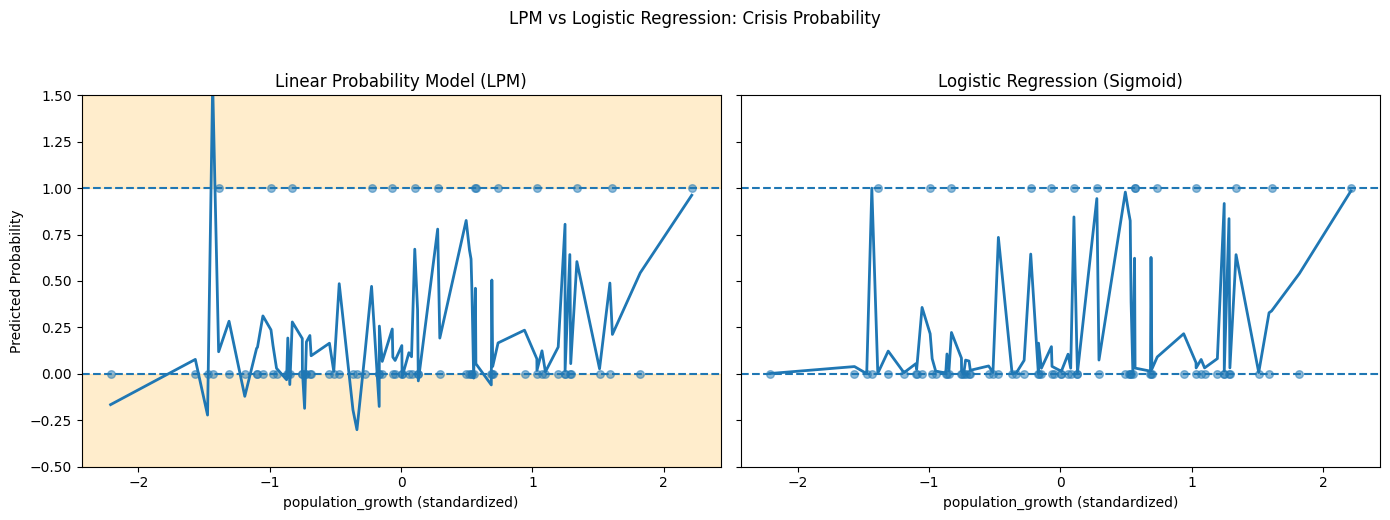

In [14]:
# Convert scaled arrays back to DataFrame (with column names)
X_train_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_cols)

# Strongest predictor
strongest_feature = "population_growth"

# Extract this feature from test set
x_test_strong = X_test_df[strongest_feature].values

# Sort for smooth curves
sort_idx = np.argsort(x_test_strong)
x_sorted = x_test_strong[sort_idx]

# Sort predictions accordingly
y_pred_lpm_sorted = y_pred_lpm[sort_idx]
y_prob_sorted = y_prob[sort_idx]
y_actual_sorted = y_test_bin[sort_idx]

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Panel 1: Linear Probability Model (LPM)
ax = axes[0]

# Shade impossible probability regions
ax.axhspan(-0.5, 0, color='orange', alpha=0.2)
ax.axhspan(1, 1.5, color='orange', alpha=0.2)

# Scatter actual outcomes (0/1)
ax.scatter(x_test_strong, y_test_bin, alpha=0.5, s=30)

# Plot LPM predictions
ax.plot(x_sorted, y_pred_lpm_sorted, linewidth=2)

# Reference lines
ax.axhline(0, linestyle='--')
ax.axhline(1, linestyle='--')

ax.set_title("Linear Probability Model (LPM)")
ax.set_xlabel("population_growth (standardized)")
ax.set_ylabel("Predicted Probability")
ax.set_ylim(-0.5, 1.5)

# Panel 2: Logistic Regression
ax = axes[1]

# Scatter actual outcomes
ax.scatter(x_test_strong, y_test_bin, alpha=0.5, s=30)

# Plot logistic predictions (sigmoid shape)
ax.plot(x_sorted, y_prob_sorted, linewidth=2)

# Reference lines
ax.axhline(0, linestyle='--')
ax.axhline(1, linestyle='--')

ax.set_title("Logistic Regression (Sigmoid)")
ax.set_xlabel("population_growth (standardized)")
ax.set_ylim(-0.5, 1.5)

# Final layout
plt.suptitle("LPM vs Logistic Regression: Crisis Probability", y=1.03)
plt.tight_layout()
plt.show()

<h1> Phase 3: Operational Deployment — Metrics That Matter

<h2> Step 3.1: The Accuracy Paradox

In [15]:
from sklearn.metrics import accuracy_score, recall_score

# Crisis base rate in the test set
crisis_base_rate = y_test_bin.mean()


# Naive baseline: always predict "no crisis" (class 0)
y_pred_naive = np.zeros_like(y_test_bin)

naive_accuracy = accuracy_score(y_test_bin, y_pred_naive)
naive_recall = recall_score(y_test_bin, y_pred_naive, pos_label=1)

# Logistic regression predictions at default threshold
y_pred_logit_05 = (y_prob >= 0.5).astype(int)
logit_accuracy = accuracy_score(y_test_bin, y_pred_logit_05)
logit_recall = recall_score(y_test_bin, y_pred_logit_05, pos_label=1)


# Print results
print(f"Test-set crisis base rate: {crisis_base_rate:.4f}")
print("Naive baseline (always predict no crisis):")
print(f"Accuracy: {naive_accuracy:.4f}")
print(f"Recall on crisis class: {naive_recall:.4f}")
print("Logistic regression (threshold = 0.5):")
print(f"Accuracy: {logit_accuracy:.4f}")
print(f"Recall on crisis class: {logit_recall:.4f}")

Test-set crisis base rate: 0.1944
Naive baseline (always predict no crisis):
Accuracy: 0.8056
Recall on crisis class: 0.0000
Logistic regression (threshold = 0.5):
Accuracy: 0.7639
Recall on crisis class: 0.4286


Would be misled if only accuracy were reported. Because the crisis base rate is low (0.1944), a naive model that always predicts “no crisis” achieves high accuracy (0.8056) while having zero recall and completely missing all crises. This illustrates the accuracy paradox that in imbalanced datasets, high accuracy can mask a model’s failure to detect the rare but critical events that matter for IMF decision-making.

<h2> Step 3.2: Confusion Matrix and Classification Report

              precision    recall  f1-score   support

           0       0.86      0.84      0.85        58
           1       0.40      0.43      0.41        14

    accuracy                           0.76        72
   macro avg       0.63      0.64      0.63        72
weighted avg       0.77      0.76      0.77        72



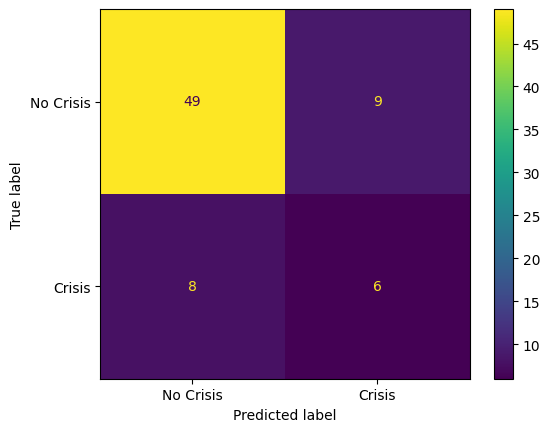

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Predictions at threshold 0.5
y_pred = (y_prob >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test_bin, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Crisis', 'Crisis'])
disp.plot()

# Classification report
print(classification_report(y_test_bin, y_pred))

In [17]:
# Extract values
TN, FP, FN, TP = cm.ravel()

print("True Positives (crises correctly flagged):", TP)
print("False Negatives (crises missed):", FN)
print("False Positives (false alarms):", FP)
print("True Negatives:", TN)

True Positives (crises correctly flagged): 6
False Negatives (crises missed): 8
False Positives (false alarms): 9
True Negatives: 49


In the IMF context, a false negative is far more costly than a false positive, because missing a crisis can trigger losses of roughly $50 billion, whereas a false alarm costs only about 2 million. This asymmetry suggests that the Division Chief should prioritize Recall, since it measures the model’s ability to correctly identify actual crises. Maximizing recall reduces the risk of missing crises, even if it leads to more false alarms.

<h2> Step 3.3: ROC and Precision-Recall Curves

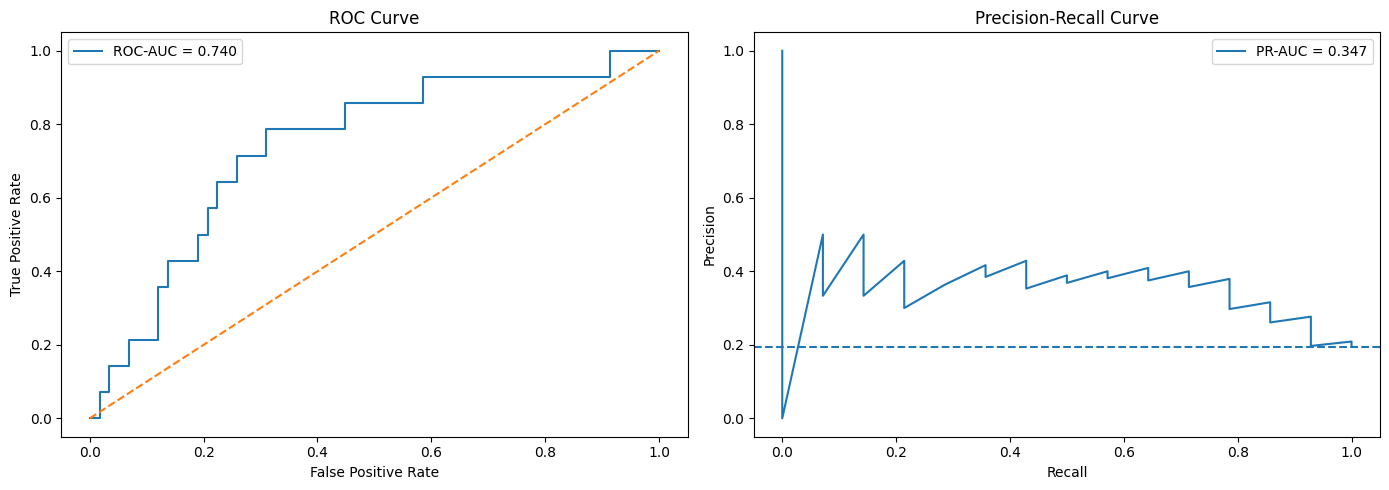

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, auc

# ROC metrics
fpr, tpr, _ = roc_curve(y_test_bin, y_prob)
roc_auc = roc_auc_score(y_test_bin, y_prob)

# PR metrics
precision, recall, _ = precision_recall_curve(y_test_bin, y_prob)
pr_auc = auc(recall, precision)

# Base rate (for PR baseline)
base_rate = y_test_bin.mean()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
ax = axes[0]
ax.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle='--')  # random classifier
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()

# PR curve
ax = axes[1]
ax.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
ax.axhline(base_rate, linestyle='--')  # baseline = base rate
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend()

plt.tight_layout()
plt.show()

In my graph, the ROC-AUC is higher than the PR-AUC because ROC incorporates True Negatives, which are abundant in this imbalanced dataset and make the model appear more effective. In contrast, the PR curve ignores True Negatives and focuses only on Precision and Recall for the crisis class, leading to a lower but more realistic assessment of performance. For the IMF’s crisis detection mission, the PR curve is more informative because it directly evaluates the model’s ability to identify rare but costly crisis events.

<h2> Step 3.4: Threshold Analysis — The 5-Mission Constraint

In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

thresholds = np.arange(0.01, 1.00, 0.01)

precisions = []
recalls = []
f1_scores = []
flagged_counts = []

for tau in thresholds:
    y_pred_tau = (y_prob >= tau).astype(int)

    precisions.append(precision_score(y_test_bin, y_pred_tau, zero_division=0))
    recalls.append(recall_score(y_test_bin, y_pred_tau, zero_division=0))
    f1_scores.append(f1_score(y_test_bin, y_pred_tau, zero_division=0))
    flagged_counts.append(np.sum(y_pred_tau))

precisions = np.array(precisions)
recalls = np.array(recalls)
f1_scores = np.array(f1_scores)
flagged_counts = np.array(flagged_counts)

In [20]:
# Find lowest threshold that flags at most 5 countries
valid_idx = np.where(flagged_counts <= 5)[0]

tau_capacity = thresholds[valid_idx[0]]
flags_capacity = flagged_counts[valid_idx[0]]
precision_capacity = precisions[valid_idx[0]]
recall_capacity = recalls[valid_idx[0]]

In [21]:
# F1-optimal threshold
best_idx = np.argmax(f1_scores)

tau_f1 = thresholds[best_idx]
precision_f1 = precisions[best_idx]
recall_f1 = recalls[best_idx]
f1_best = f1_scores[best_idx]

In [22]:
print("Capacity-constrained threshold:")
print(f"tau = {tau_capacity:.2f}")
print(f"Flagged countries = {flags_capacity}")
print(f"Precision = {precision_capacity:.3f}")
print(f"Recall = {recall_capacity:.3f}")
print()

print("F1-optimal threshold:")
print(f"tau = {tau_f1:.2f}")
print(f"Precision = {precision_f1:.3f}")
print(f"Recall = {recall_f1:.3f}")
print(f"F1 = {f1_best:.3f}")

Capacity-constrained threshold:
tau = 0.88
Flagged countries = 5
Precision = 0.400
Recall = 0.143

F1-optimal threshold:
tau = 0.13
Precision = 0.400
Recall = 0.714
F1 = 0.513


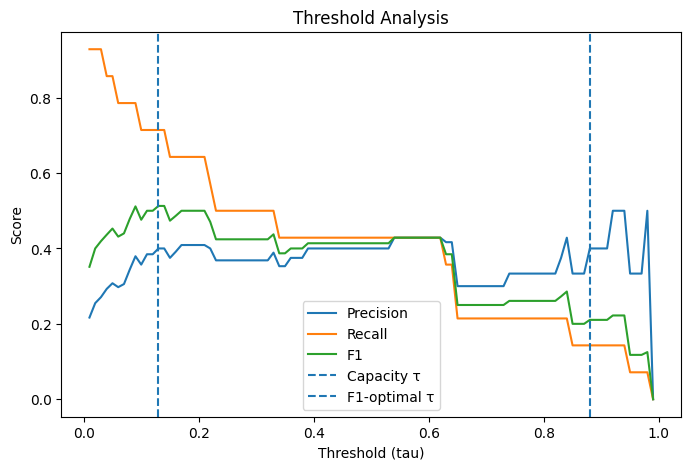

In [23]:
plt.figure(figsize=(8,5))

plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1_scores, label="F1")

plt.axvline(tau_capacity, linestyle='--', label="Capacity τ")
plt.axvline(tau_f1, linestyle='--', label="F1-optimal τ")

plt.xlabel("Threshold (tau)")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.legend()

plt.show()

I recommend adopting the capacity-constrained threshold 0.88, which flags 5 countries and achieves a recall of 0.143. In operational terms, out of 14 crisis countries, the IMF would identify about 2 and miss 12. While the F1-optimal threshold (0.13) captures about 10 crises (recall = 0.714), it exceeds the IMF’s mission capacity. This suggests a tradeoff that the feasible threshold respects resource constraints but results in many missed crises, whereas a lower threshold improves detection at the cost of operational limits. In this case, under the current constraint, threshold 0.88 is the most practical choice.

<h1> Phase 4: AI Context Engineering (The P.R.I.M.E. Framework)

<h2> Task 4.1: Bootstrap Confidence Intervals for the Lasso Path

Prompt:

I am analyzing macroeconomic indicators (WDI data) using Lasso regression to predict GDP growth. The predictors are standardized, and I have already fit a LassoCV model and identified selected features. However, due to multicollinearity among macroeconomic variables, I want to assess the stability of feature selection using bootstrap resampling.

Write a Python script that performs bootstrap-based stability selection for Lasso. Specifically:
1. Draw 200 bootstrap samples (with replacement) from the training data (X_train_scaled, y_train).
2. For each bootstrap sample, fit a LassoCV model (5-fold CV) using the same alpha grid.
3. Record which predictors have non-zero coefficients in each bootstrap iteration.
4. Compute the selection frequency for each predictor as the fraction of times it is selected (non-zero coefficient).
5. Store results in a pandas DataFrame sorted by selection frequency.
6. Plot a horizontal bar chart of selection frequencies, with predictors on the y-axis and frequency on the x-axis.
7. Add a vertical dashed line at 0.5 to indicate the stability threshold.

Ensure the code is efficient and avoids unnecessary loops where possible. Use numpy and pandas for data handling and matplotlib or seaborn for plotting.

Explain briefly how bootstrap resampling captures instability due to correlated predictors, and why selection frequency is a useful diagnostic.

The output should include a clean DataFrame and a well-labeled plot. The code should be reproducible and compatible with standard scikit-learn workflows.

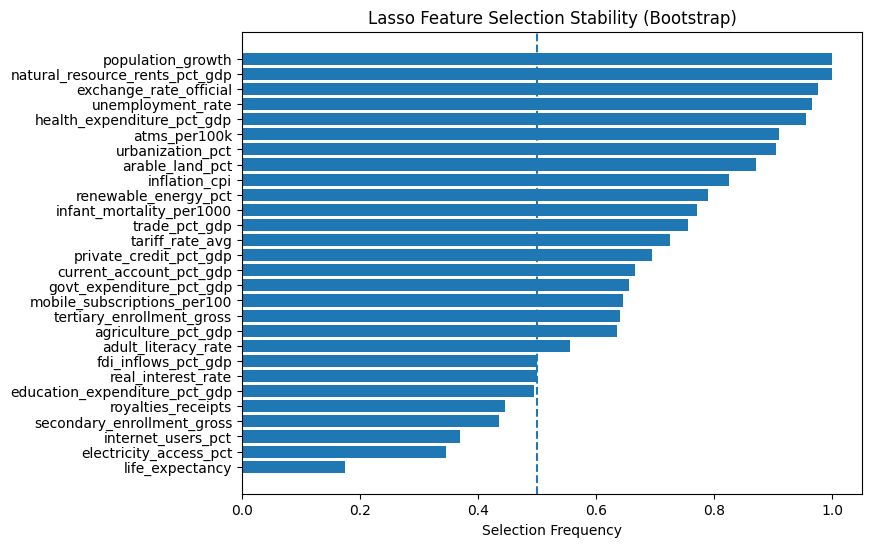

,Feature,Selection Frequency
24,life_expectancy,0.175
4,electricity_access_pct,0.345
12,internet_users_pct,0.370
18,secondary_enrollment_gross,0.435
2,royalties_receipts,0.445
20,education_expenditure_pct_gdp,0.495
9,real_interest_rate,0.500
3,fdi_inflows_pct_gdp,0.500
17,adult_literacy_rate,0.555
14,agriculture_pct_gdp,0.635


In [24]:
# Bootstrap Lasso Stability Selection

from sklearn.linear_model import LassoCV
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

n_bootstrap = 200
n_features = X_train_scaled.shape[1]

selection_counts = np.zeros(n_features)

alphas = np.logspace(-3, 3, 100)

for i in range(n_bootstrap):
    # bootstrap sample indices
    idx = np.random.choice(len(X_train_scaled), size=len(X_train_scaled), replace=True)

    X_boot = X_train_scaled[idx]
    y_boot = y_train[idx]

    model = LassoCV(alphas=alphas, cv=5, max_iter=10000)
    model.fit(X_boot, y_boot)

    selection_counts += (model.coef_ != 0)

# compute selection frequency
selection_freq = selection_counts / n_bootstrap

# create DataFrame
stability_df = pd.DataFrame({
    "Feature": feature_cols,
    "Selection Frequency": selection_freq
}).sort_values(by="Selection Frequency", ascending=True)

# plot
plt.figure(figsize=(8,6))
plt.barh(stability_df["Feature"], stability_df["Selection Frequency"])
plt.axvline(0.5, linestyle='--')
plt.xlabel("Selection Frequency")
plt.title("Lasso Feature Selection Stability (Bootstrap)")
plt.show()

stability_df

The stable predictors (selected more than 80% of the time) include population_growth, natural_resource_rents_pct_gdp, exchange_rate_official, unemployment_rate, and health_expenditure_pct_gdp, while the most fragile predictor (selected less than 30%) is life_expectancy. This selection instability reflects the strong correlation structure among WDI indicators, where multiple variables capture similar underlying dimensions of development such as health, income, and infrastructure. As a result, Lasso may alternate between correlated predictors across bootstrap samples, indicating that individual variable selection is sensitive to the sample and should be interpreted cautiously.

<h2> Task 4.2: Cost-Sensitive Threshold Optimization

Prompt:

I have already fit a logistic regression crisis classifier and computed predicted probabilities for the test set in a variable called `y_prob`. The true binary crisis labels for the same test set are stored in `y_test_bin`. In this IMF setting, a False Negative (missed crisis) costs $50 billion, and a False Positive (false alarm) costs $2 million.

Write Python code that sweeps classification thresholds from 0.01 to 0.99 in increments of 0.01. At each threshold, convert predicted probabilities into class predictions and compute the confusion matrix. Using the confusion matrix, calculate total expected cost as:  
Total Cost = FN * 50_000_000_000 + FP * 2_000_000
Store threshold, false positives, false negatives, and total cost in a pandas DataFrame. Identify the threshold that minimizes total expected cost. Plot total expected cost against threshold, and annotate the cost-minimizing threshold on the chart.

Make the code clean, reproducible, and easy to read. Use pandas, numpy, matplotlib, and scikit-learn only. Label axes clearly and format the y-axis in billions of dollars for readability.

Briefly explain in code comments why the optimal threshold may be much lower than 0.5 when false negatives are dramatically more expensive than false positives.

The final output should include a printed summary of the cost-minimizing threshold, its false positives, false negatives, and total expected cost, plus a clearly labeled plot.

Cost-minimizing threshold:
tau = 0.03
False Positives = 35
False Negatives = 1
Total Expected Cost = $50,070,000,000


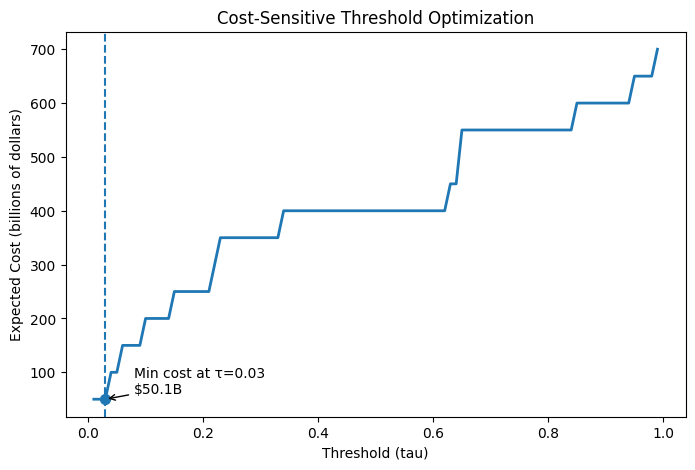

In [25]:
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

thresholds = np.arange(0.01, 1.00, 0.01)

results = []

fn_cost = 50_000_000_000
fp_cost = 2_000_000

for tau in thresholds:
    y_pred_tau = (y_prob >= tau).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_bin, y_pred_tau).ravel()
    total_cost = fn * fn_cost + fp * fp_cost

    results.append({
        "threshold": tau,
        "false_positives": fp,
        "false_negatives": fn,
        "total_cost": total_cost
    })

cost_df = pd.DataFrame(results)

best_idx = cost_df["total_cost"].idxmin()
best_row = cost_df.loc[best_idx]

tau_cost = best_row["threshold"]
fp_cost_min = int(best_row["false_positives"])
fn_cost_min = int(best_row["false_negatives"])
total_cost_min = best_row["total_cost"]

print("Cost-minimizing threshold:")
print(f"tau = {tau_cost:.2f}")
print(f"False Positives = {fp_cost_min}")
print(f"False Negatives = {fn_cost_min}")
print(f"Total Expected Cost = ${total_cost_min:,.0f}")

plt.figure(figsize=(8, 5))
plt.plot(cost_df["threshold"], cost_df["total_cost"] / 1e9, linewidth=2)
plt.axvline(tau_cost, linestyle="--")
plt.scatter([tau_cost], [total_cost_min / 1e9], s=50)

plt.xlabel("Threshold (tau)")
plt.ylabel("Expected Cost (billions of dollars)")
plt.title("Cost-Sensitive Threshold Optimization")

plt.annotate(
    f"Min cost at τ={tau_cost:.2f}\n${total_cost_min/1e9:.1f}B",
    xy=(tau_cost, total_cost_min / 1e9),
    xytext=(tau_cost + 0.05, total_cost_min / 1e9 + 10),
    arrowprops=dict(arrowstyle="->")
)

plt.show()

The cost-minimizing threshold (0.03) is much lower than both the F1-optimal threshold (0.13) and the capacity-constrained threshold (0.88), reflecting the extreme cost asymmetry between false negatives and false positives. Because missing a crisis is vastly more expensive, the cost-based threshold aggressively prioritizes recall, even at the expense of many false alarms. I would recommend the cost-minimizing threshold if the objective is to minimize expected losses, but in practice the IMF may need to balance this with operational constraints, making the capacity-constrained threshold more feasible.